In [1950]:

try:
    import serial
    import numpy as np
    from matplotlib import pyplot as plt
except:
    %pip install pyserial
    %pip install numpy
    %pip install matplotlib
    import serial
    import numpy as np
    from matplotlib import pyplot as plt

In [1951]:
path_port_serial = "/dev/ttyUSB1"

In [1952]:
#l = serial.Serial()
#l.port=path_port_serial
#l.baudrate = 115200
#l.bytesize = 8
#l.open()
#l.write(bytearray([2]))
#l.close()



In [1953]:
import random as rd
import time

In [1954]:
def print_matrix(X):
  cmp = len(str(X[0][0]))
  for i in range(X.shape[0]):
    for j in range(X.shape[1]):
      if(X[i][j] ==0):
        print(f'0'*cmp,end=' ')
      else:
#        print(f'{bin(X[i][j])}',end=' ')

        print(f'{X[i][j]:01d}',end=' ')
    print()

In [1955]:
def create_matrix(Din,BitsPorSimbolo):
  #Din = 8 #Diminsão das matrizes
  #DigitosPorSimbolo = 1 #digitos por elementos das matrizes
  Ain = np.zeros((Din,Din),dtype=int)
  Bin = np.zeros((Din,Din),dtype=int)
  for i in range(Din):
    for j in range(Din):
      Ain[i][j] = rd.randint(1*(BitsPorSimbolo),1*2**(BitsPorSimbolo))
      Bin[i][j] = rd.randint(1*(BitsPorSimbolo),1*2**(BitsPorSimbolo))
  return [Ain,Bin]

In [1956]:
#Preprocessamendo das matrizes
def shiftMatrixSystolic(X1:np.ndarray,X2:np.ndarray):
  Y1 = np.zeros((X1.shape[0],2*X1.shape[0]-1),dtype=int)
  Y2 = np.zeros((X2.shape[0],2*X2.shape[0]-1),dtype=int)
  for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
      if(j < X1.shape[1]):
        Y1[i][j+X1.shape[0]-i-1] = X1[i][j]
        Y2[i][j+X1.shape[0]-i-1] = X2[j][i]
        #Y2[i+j][j] = X2[i][j] #Transposta do segundo operando
        #Y2[i+j][i] = X2[i][j]
      else:
        Y1[i][j] = 0
        Y2[i][j] = 0
  return [Y1,Y2]


In [1957]:
#plt.subplot(1,2,1)
#plt.imshow(Ain)
#plt.subplot(1,2,2)
#plt.imshow(Bin)
#plt.show()


In [1958]:
#plt.subplot(1,2,1)
#plt.imshow(Ms[0])
#plt.subplot(1,2,2)#
#plt.imshow(Ms[1])
#plt.show()

In [1959]:
def send_matrix(X,input,flag,k=0):
  file = open(f"teste{input}.txt","+w")
  size = X.shape[0]
  Y = np.zeros((size,size),dtype=int)
  fs_fpga2pc_rate = 5e+3
  fs_pc2fpga_rate = 15e+3
  s = serial.Serial()
  s.port = path_port_serial
  s.baudrate = 115200
  s.bytesize = 8
  #fs_pc2fpga_rate = (s.baudrate)*(s.bytesize+2)*(1+1)#8 bits de dados e 1 de start 1 de stop

  s.open()
  s.write(bytearray([255]))
  time.sleep(1/fs_pc2fpga_rate)
  s.write(bytearray([255]))
  time.sleep(1/fs_pc2fpga_rate)
  for i in range(X.shape[1]):
    for j in range(X.shape[0]):
      s.write(bytearray([X[j][i]]))
      time.sleep(1/fs_pc2fpga_rate)
  if(k):
    s.write(bytearray([0xaa]))
    time.sleep(1/fs_pc2fpga_rate)
    s.write(bytearray([0xaa]))
    time.sleep(1/fs_pc2fpga_rate)
  else:
    s.write(bytearray([0xaa]))
    time.sleep(1/fs_pc2fpga_rate)
    s.write(bytearray([0xaa]))
    time.sleep(1/fs_pc2fpga_rate)
    #for i in range(size):
    #  for j in range(size):
    #    #Y[i][j] = s.read()[0]
    #    time.sleep(1/fs_fpga2pc_rate)
  
  s.close()  
  s.close()  
  return Y
 

In [1960]:
M = create_matrix(Din = 4, BitsPorSimbolo=np.log2(2))
M

[array([[1, 2, 1, 2],
        [1, 2, 1, 1],
        [1, 1, 2, 1],
        [2, 2, 2, 2]]),
 array([[1, 1, 2, 1],
        [2, 1, 2, 1],
        [2, 1, 1, 2],
        [1, 1, 1, 1]])]

In [1961]:
M_p = shiftMatrixSystolic(M[0],M[1])

In [1962]:
M_p

[array([[0, 0, 0, 1, 2, 1, 2],
        [0, 0, 1, 2, 1, 1, 0],
        [0, 1, 1, 2, 1, 0, 0],
        [2, 2, 2, 2, 0, 0, 0]]),
 array([[0, 0, 0, 1, 2, 2, 1],
        [0, 0, 1, 1, 1, 1, 0],
        [0, 2, 2, 1, 1, 0, 0],
        [1, 1, 2, 1, 0, 0, 0]])]

In [1963]:
for i in range(1):
    print("Matriz -----------------------",i,"--------------------------")
    #print(M[0]@M[1])
    #M = create_matrix(Din = 16, BitsPorSimbolo=np.log2(1))
    M_p = shiftMatrixSystolic(M[0],M[1])
    send_matrix(M_p[0],"INPUT_A1",1,k=1)
    send_matrix(M_p[1],"INPUT_B1",1,k=0)
    #rec_matrix(4)
    #rec_matrix(M[0].shape[0])
    print(M[0]@M[1])
    print(0)
#    time.sleep(10)


Matriz ----------------------- 0 --------------------------
[[ 9  6  9  7]
 [ 8  5  8  6]
 [ 8  5  7  7]
 [12  8 12 10]]
0


## Representação do problema 
         OPA   OPB
 ....f000776af000776a_f000776a0f00776....
 ....f001370af001370a_f001370a0f01370....
 ....f031100af031100a_f031100a0f31100....
 ....f193000af193000a_f193000a1f93000....



In [1995]:
def send_matrix_rec(X,input):
  file = open(f"teste{input}.txt","+w")
  fs_pc2fpga_rate = 4e+3
  s = serial.Serial()
  s.port = path_port_serial
  s.baudrate = 115200
  s.bytesize = 8
  #fs_pc2fpga_rate = (s.baudrate)*(s.bytesize+2)*(1+1)#8 bits de dados e 1 de start 1 de stop
  s.open()
  s.write(bytearray([0xff]))
  time.sleep(1/fs_pc2fpga_rate)
  s.write(bytearray([0xff]))
  time.sleep(1/fs_pc2fpga_rate)
  for i in range(X.shape[1]):
    for j in range(X.shape[0]):
      s.write(bytearray([X[j][i]]))
      time.sleep(1/fs_pc2fpga_rate)
  s.write(bytearray([0xad]))
  time.sleep(1/fs_pc2fpga_rate)
  s.write(bytearray([0xda]))
  time.sleep(1/fs_pc2fpga_rate)
  #if(k):
    #for i in range(size):
    #  for j in range(size):
    #    #Y[i][j] = s.read()[0]
    #    print(s.read()[0])
    #    #time.sleep(1/(fs_fpga2pc_rate))
    #s.close()
    #while(True):
    #  print(s.read()[0])  
    #  time.sleep(1/(fs_fpga2pc_rate))
  s.close()  

 

In [1965]:
M = create_matrix(Din = 4, BitsPorSimbolo=np.log2(2))
M

[array([[1, 1, 1, 2],
        [2, 1, 1, 1],
        [2, 2, 1, 2],
        [1, 1, 1, 2]]),
 array([[1, 2, 2, 2],
        [2, 1, 2, 2],
        [2, 1, 1, 1],
        [1, 1, 2, 1]])]

In [1966]:
M[0].shape[1]

4

In [1967]:
M[0].shape[0]

4

In [1968]:
def transmitter_uart(M):
    M_p = shiftMatrixSystolic(M[0],M[1])
    send_matrix_rec(M_p[0],"INPUT_A1")
    send_matrix_rec(M_p[1],"INPUT_B1")

In [1969]:
def receiver_uart(size):
    s = serial.Serial()
    s.port = path_port_serial
    s.baudrate = 115200
    s.bytesize = 8
    s.open()
    Y= np.zeros((size,size),dtype=int)
    i = 0

    index_row = 0
    index_col = 0
    flag =0
    s.write(bytearray([0xea]))
    s.write(bytearray([0xea]))
    while(True):
        a = s.read()[0]
        if(a!=0 and a!=254 and a!=239):
            i+=1
            Y[index_row][index_col] = a
            #print(a,index_row,index_col)
            index_col +=1
            if(index_col == size):
                index_row +=1
                if(index_col == size-1 and index_row == size-1):
                    flag = 1
                    break
                index_col = 0
        if(i == size**2 or flag ):
            break


        #if(a==0):
        #    break
    s.close()
    return Y

In [1970]:
def receiver_uart_linear(size):
    fpga2pc_rate = 10472
    s = serial.Serial()
    s.port = path_port_serial
    s.baudrate = 115200
    s.bytesize = 8
    s.open()
    Y= np.zeros((size*size),dtype=int)
    i = 0
    while(True):
        if(i==0):
            s.write(bytearray([0xea]))
            s.write(bytearray([0xea]))
        a = s.read()[0]
        if(a!=0 and a!=254 and a!=239):
            Y[i] = a
            print(a)
            i+=1
        if(i == size**2):
            break


        #if(a==0):
        #    break
    s.close()
    return Y

In [1971]:
print(0xfe,0xef)

254 239


In [1972]:
def compar_matrix(M1,M2):
    for i in range(M1.shape[0]):
        for j in range(M1.shape[0]):
            if(M1[i][j]!=M2[i][j]):
                return 1
    return 0

In [1973]:
for i in range(1):
    print("Matriz -----------------------",i,"--------------------------")
    #print(M[0]@M[1])
    M = create_matrix(Din =4, BitsPorSimbolo=np.log2(2))
    X =M[0]@M[1]
    transmitter_uart(M)
    time.sleep(1)#Representação do Atraso para calcular
    Y = receiver_uart(M[0].shape[0])
    #print("\nAlvo: PC")
    #print_matrix(X)
    #print("\nObtido: FPGA ")
    #print_matrix(Y)
    if(compar_matrix(X,Y)):
        print('Fail:')
        print("\nAlvo: PC")
        print_matrix(X)
        print("\nObtido: FPGA ")
        print_matrix(Y)       
        break
    else:
        print("Pass")
    time.sleep(1)# 10.472kHz


Matriz ----------------------- 0 --------------------------


KeyboardInterrupt: 

In [1996]:
for i in range(1):
    print("Matriz -----------------------",i,"--------------------------")
    #print(M[0]@M[1])
    M = create_matrix(Din =4, BitsPorSimbolo=np.log2(1))
    X =M[0]@M[1]
    transmitter_uart(M)
    #time.sleep(1)#Representação do Atraso para calcular
    Y = receiver_uart(M[0].shape[0])
    print("\nAlvo: PC")
    print_matrix(X)
    print("\nObtido: FPGA ")
    print_matrix(Y)



Matriz ----------------------- 0 --------------------------


KeyboardInterrupt: 

In [1991]:
M = create_matrix(Din =16, BitsPorSimbolo=np.log2(2))
X =M[0]@M[1]
transmitter_uart(M)
#time.sleep(1)#Representação do Atraso para calcular
Y = receiver_uart(M[0].shape[0])
print("\nAlvo: PC")
print_matrix(X)
print("\nObtido: FPGA ")
print_matrix(Y)


Alvo: PC
29 31 30 28 33 27 29 28 28 29 35 29 29 32 28 28 
33 36 34 31 37 29 34 31 33 32 38 31 33 35 33 31 
37 43 39 36 42 36 39 35 36 37 47 38 37 42 39 36 
35 39 37 35 41 36 37 33 33 35 46 38 34 40 37 36 
40 44 41 39 44 38 41 39 38 42 49 40 41 45 42 41 
34 34 34 31 37 33 34 30 30 34 40 34 33 37 36 34 
34 37 36 32 37 30 32 32 31 34 41 33 33 37 33 33 
37 40 40 36 41 33 36 34 33 37 45 37 35 39 38 37 
37 41 40 36 41 34 39 36 36 37 45 37 39 43 38 39 
32 34 33 29 35 30 31 31 29 32 38 31 31 37 32 31 
37 38 38 34 39 35 36 35 33 36 43 37 36 42 37 37 
32 37 34 33 38 30 34 32 32 34 41 33 33 37 33 34 
34 38 36 32 40 33 36 33 33 35 42 33 34 39 36 33 
34 37 37 34 38 34 35 32 32 35 43 36 35 38 35 36 
36 38 36 33 40 35 36 34 33 34 43 35 32 39 38 33 
36 39 39 35 40 33 36 34 34 34 42 36 34 38 36 34 

Obtido: FPGA 
27 25 30 26 28 27 26 29 33 26 28 32 29 27 5 3 
31 30 33 29 31 28 28 32 38 32 31 34 32 30 7 5 
35 34 37 34 35 34 32 33 43 36 33 38 38 33 10 6 
33 31 36 33 33 33 30 32 40 33 31 38 36 32 9 6 
38

In [ ]:
receiver_uart_linear(M[0].shape[0])

KeyboardInterrupt: 

In [ ]:
a = b'\x11'
int(hex(int(a[0]))[2:])


11

In [ ]:
for i in range(2):
    print("Matriz -----------------------",i,"--------------------------")
    #M = create_matrix(Din = 4, BitsPorSimbolo=np.log2(2))
    M_p = shiftMatrixSystolic(M[0],M[1])
    print(M[0]@M[1])
    send_matrix(M_p[0],"INPUT_A1",1,k=1)
    send_matrix(M_p[1],"INPUT_B1",1,k=0)
    
    #time.sleep(10)


Matriz ----------------------- 0 --------------------------
[[ 93  58  60  47]
 [139  84  66  59]
 [ 91  56  64  51]
 [115  76  54  43]]
Matriz ----------------------- 1 --------------------------
[[ 93  58  60  47]
 [139  84  66  59]
 [ 91  56  64  51]
 [115  76  54  43]]


In [ ]:
M[0]

array([[3, 6, 2, 6],
       [7, 4, 6, 6],
       [3, 6, 4, 4],
       [7, 4, 2, 6]])

In [ ]:
M[1]

array([[2, 4, 6, 7],
       [1, 4, 6, 5],
       [7, 4, 2, 1],
       [7, 7, 4, 4]])

In [ ]:
M[0]@M[1]

array([[ 45,  53,  52,  52],
       [ 51,  47,  44,  42],
       [ 72,  76,  68,  60],
       [ 91, 111, 114, 109]])

In [ ]:
M[1]@M[0]

array([[85, 87, 89, 69],
       [67, 71, 77, 56],
       [55, 35, 49, 38],
       [92, 69, 89, 64]])

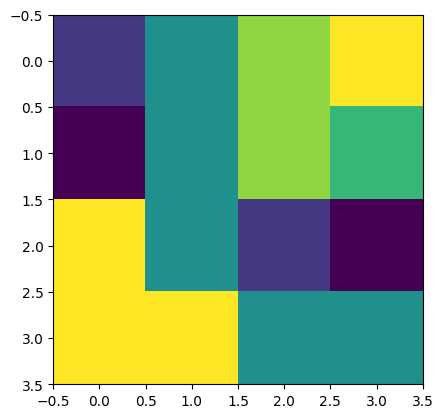

In [ ]:
plt.imshow(M[1])

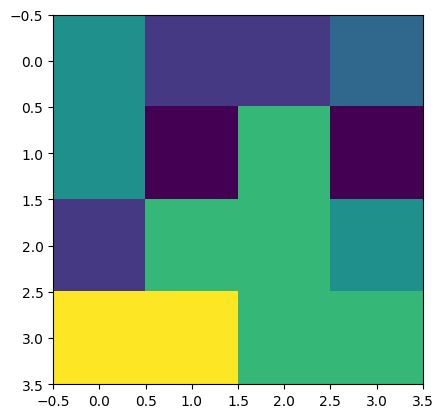

In [ ]:
plt.imshow(M[0])

In [ ]:
M[0]@M[1]

array([[ 45,  53,  52,  52],
       [ 51,  47,  44,  42],
       [ 72,  76,  68,  60],
       [ 91, 111, 114, 109]])

M_p = shiftMatrixSystolic(M[0],M[1])

In [ ]:
M[1]@M[0]

array([[85, 87, 89, 69],
       [67, 71, 77, 56],
       [55, 35, 49, 38],
       [92, 69, 89, 64]])

In [ ]:
M[0]@M[1]

array([[ 45,  53,  52,  52],
       [ 51,  47,  44,  42],
       [ 72,  76,  68,  60],
       [ 91, 111, 114, 109]])

In [ ]:
M_p = shiftMatrixSystolic(M[0],M[0])
M_p[0],M_p[1]

(array([[0, 0, 0, 4, 2, 2, 3],
        [0, 0, 4, 1, 5, 1, 0],
        [0, 2, 5, 5, 4, 0, 0],
        [7, 7, 5, 5, 0, 0, 0]]),
 array([[0, 0, 0, 4, 4, 2, 7],
        [0, 0, 2, 1, 5, 7, 0],
        [0, 2, 5, 5, 5, 0, 0],
        [3, 1, 4, 5, 0, 0, 0]]))

In [ ]:
#M = create_matrix(Din = 16, PorSimbolo=1)

In [ ]:
M[0]@M[1]

array([[ 45,  53,  52,  52],
       [ 51,  47,  44,  42],
       [ 72,  76,  68,  60],
       [ 91, 111, 114, 109]])

In [ ]:
M

[array([[4, 2, 2, 3],
        [4, 1, 5, 1],
        [2, 5, 5, 4],
        [7, 7, 5, 5]]),
 array([[2, 4, 6, 7],
        [1, 4, 6, 5],
        [7, 4, 2, 1],
        [7, 7, 4, 4]])]

In [ ]:
M_p[0]

array([[0, 0, 0, 4, 2, 2, 3],
       [0, 0, 4, 1, 5, 1, 0],
       [0, 2, 5, 5, 4, 0, 0],
       [7, 7, 5, 5, 0, 0, 0]])

In [ ]:
M_p[1]

array([[0, 0, 0, 4, 4, 2, 7],
       [0, 0, 2, 1, 5, 7, 0],
       [0, 2, 5, 5, 5, 0, 0],
       [3, 1, 4, 5, 0, 0, 0]])

In [ ]:
def send_matrix1(X,input,flag):
  file = open(f"../teste{input}.mem","+w")
  #file.write(f"assign {input}[{0}] = "+"32'"+"h"+str("ffffffff")+";\n")
  k = 0
  file.write(f'{0XFF:02X}'+"\n")
  file.write(f'{0XFF:02X}'+"\n")
  for i in range(X.shape[1]):
    strbin = 0
    for j in range(X.shape[0]):
        file.write(f'{X[j][i]:02d}'+"\n")
        #file.write(f"assign {input}[{k:03}] = "+"8'"+"h"+f'{X[j][i]:02d}'+";\n")
        k =k+1
        #strbin+= int(X[j][i]*pow(10,X.shape[0]-1-j))
    #print(f'{strbin:016d}',i)
   # print(int('0b'+strbin,2))
   # file.write(f"assign {input}[{i+1}] = "+"32'"+"h"+f'{strbin:08d}'+";\n")
  #file.close()
  file.write(f'{0XAD:02X}'+"\n")
  file.write(f'{0XDA:02X}'+"\n")
for i in range(1):
    print("----------------------",i,"--------------------------")
    M_p = shiftMatrixSystolic(M[0],M[1])
    #Bin = M[1]
    send_matrix1(M_p[0],"INPUT_A1",0)
    send_matrix1(M_p[1],"INPUT_B1",0)
    
    break
    time.sleep(10)

#send_matrix(Bin)

---------------------- 0 --------------------------


In [ ]:
M[0]@M[1]

array([[1, 1, 4, 3, 4, 2, 4, 4, 4, 4, 4, 3, 3, 3, 3, 4],
       [1, 2, 7, 5, 4, 4, 5, 7, 7, 7, 6, 7, 4, 6, 4, 6],
       [4, 3, 8, 6, 4, 4, 7, 4, 6, 7, 7, 5, 7, 7, 3, 7],
       [3, 3, 4, 4, 0, 4, 3, 3, 3, 4, 2, 4, 3, 3, 2, 4],
       [2, 2, 8, 6, 4, 4, 6, 5, 5, 7, 7, 5, 6, 7, 4, 6],
       [2, 4, 7, 4, 3, 4, 6, 3, 5, 8, 7, 5, 5, 6, 4, 6],
       [4, 3, 5, 5, 1, 5, 4, 4, 5, 6, 6, 4, 3, 5, 3, 6],
       [2, 2, 6, 4, 3, 3, 5, 4, 5, 7, 7, 3, 4, 5, 4, 5],
       [2, 2, 5, 4, 4, 2, 5, 3, 5, 6, 5, 3, 3, 5, 2, 4],
       [1, 3, 6, 5, 4, 3, 4, 5, 5, 6, 6, 6, 2, 4, 4, 6],
       [3, 4, 7, 5, 4, 3, 6, 4, 4, 7, 5, 6, 5, 5, 4, 7],
       [2, 2, 4, 3, 2, 2, 3, 3, 5, 4, 5, 5, 2, 2, 2, 5],
       [2, 2, 4, 3, 1, 4, 3, 2, 3, 5, 3, 4, 4, 4, 3, 4],
       [2, 3, 7, 3, 4, 2, 6, 3, 6, 6, 7, 5, 6, 4, 3, 6],
       [2, 1, 4, 3, 2, 3, 4, 3, 3, 4, 4, 3, 3, 3, 3, 4],
       [4, 3, 6, 5, 4, 3, 6, 2, 5, 7, 6, 3, 5, 5, 3, 6]])

0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 1 
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 0 1 1 1 0 1 0 1 0 
0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 1 1 1 0 1 1 0 0 1 0 1 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 1 0 1 1 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 1 1 0 1 0 1 0 0 1 0 1 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 1 0 1 1 1 0 0 1 0 0 0 1 1 1 1 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 1 0 1 0 1 1 1 0 1 0 1 0 0 1 1 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 1 1 0 1 0 1 0 0 1 0 1 1 0 1 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 1 0 0 1 0 0 1 1 0 1 0 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 1 1 0 1 1 0 1 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 
0 0 0 1 0 0 1 0 1 1 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 
0 0 0 1 1 1 0 0 1 1 1 1 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 
0 1 0 0 1 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 
0 1 0 1 1 0 1 0 1 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0

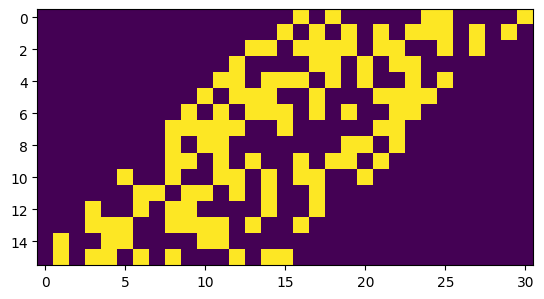

In [ ]:
print_matrix(M_p[0])
plt.imshow(M_p[0])

In [ ]:
M[0]@M[1]

array([[ 45,  53,  52,  52],
       [ 51,  47,  44,  42],
       [ 72,  76,  68,  60],
       [ 91, 111, 114, 109]])

In [ ]:
M_p[1]

array([[0, 0, 0, 2, 1, 7, 7],
       [0, 0, 4, 4, 4, 7, 0],
       [0, 6, 6, 2, 4, 0, 0],
       [7, 5, 1, 4, 0, 0, 0]])

In [ ]:
M_p[0]

array([[0, 0, 0, 4, 2, 2, 3],
       [0, 0, 4, 1, 5, 1, 0],
       [0, 2, 5, 5, 4, 0, 0],
       [7, 7, 5, 5, 0, 0, 0]])

In [ ]:
print_matrix(M[0]@M[1])

045 053 052 052 
051 047 044 042 
072 076 068 060 
091 111 114 109 


In [ ]:
M[0]@M[1]

array([[ 45,  53,  52,  52],
       [ 51,  47,  44,  42],
       [ 72,  76,  68,  60],
       [ 91, 111, 114, 109]])

In [ ]:
shiftMatrixSystolic(M[0],M[1])

[array([[0, 0, 0, 4, 2, 2, 3],
        [0, 0, 4, 1, 5, 1, 0],
        [0, 2, 5, 5, 4, 0, 0],
        [7, 7, 5, 5, 0, 0, 0]]),
 array([[0, 0, 0, 2, 1, 7, 7],
        [0, 0, 4, 4, 4, 7, 0],
        [0, 6, 6, 2, 4, 0, 0],
        [7, 5, 1, 4, 0, 0, 0]])]

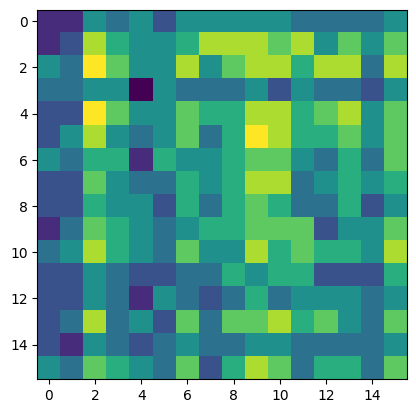

In [ ]:
plt.imshow(M[0]@M[1])

plt.show()

In [ ]:

#for i in range(100):
#    print("----------------------",i,"--------------------------")
#    M_p = shiftMatrixSystolic(M[0],M[1])
#    #Bin = M[1]
#    send_matrix(M_p[0],"INPUT_A1",0)
#    send_matrix(M_p[1],"INPUT_B1",0)
#    
#    break
#    time.sleep(10)
#
#send_matrix(Bin)

In [ ]:
M[0]

array([[4, 2, 2, 3],
       [4, 1, 5, 1],
       [2, 5, 5, 4],
       [7, 7, 5, 5]])

In [ ]:
M[1]

array([[2, 4, 6, 7],
       [1, 4, 6, 5],
       [7, 4, 2, 1],
       [7, 7, 4, 4]])

In [ ]:
M[0]@M[1]

array([[ 45,  53,  52,  52],
       [ 51,  47,  44,  42],
       [ 72,  76,  68,  60],
       [ 91, 111, 114, 109]])

In [ ]:
s = serial.Serial()

s.port = path_port_serial
s.baudrate = 115200
s.bytesize = 8
s.close()
s.open()

In [ ]:
i =1
s.write(bytearray([int(i)]))


1

In [ ]:
serial.Serial()

Serial<id=0x7fa793ec0a60, open=False>(port=None, baudrate=9600, bytesize=8, parity='N', stopbits=1, timeout=None, xonxoff=False, rtscts=False, dsrdtr=False)